# Capstone Report Notebook Shell

Use this notebook as the **narrative notebook** for your capstone.

This notebook is **not** the main engine. The main engine is:

- `run_pipeline.py`
- `dashboard_app.py`

Recommended workflow:

1. update `fund_manager_control.xlsx`
2. run `python run_pipeline.py`
3. launch `streamlit run dashboard_app.py`
4. use this notebook to organize analysis, interpretation, and report-ready tables/figures


## 0. Setup and Project Paths

This cell sets project paths and loads the most common output tables.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TABLES_DIR exists:", TABLES_DIR.exists())
print("FIGURES_DIR exists:", FIGURES_DIR.exists())

def safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"[missing] {path.name}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"[error] {path.name}: {exc}")
        return pd.DataFrame()

tables = {
    "inputs": safe_read_csv(TABLES_DIR / "tbl_inputs.csv"),
    "constraints": safe_read_csv(TABLES_DIR / "tbl_constraints.csv"),
    "inherited": safe_read_csv(TABLES_DIR / "tbl_inherited_fund.csv"),
    "candidates": safe_read_csv(TABLES_DIR / "tbl_candidates.csv"),
    "portfolio": safe_read_csv(TABLES_DIR / "tbl_portfolio_summary.csv"),
    "performance": safe_read_csv(TABLES_DIR / "tbl_performance_summary.csv"),
    "legacy_daily": safe_read_csv(TABLES_DIR / "tbl_legacy_fund_daily.csv"),
    "candidate_screen": safe_read_csv(TABLES_DIR / "tbl_candidate_screen.csv"),
    "static_compare": safe_read_csv(TABLES_DIR / "tbl_backtest_legacy_static_benchmark.csv"),
    "active_compare": safe_read_csv(TABLES_DIR / "tbl_backtest_legacy_static_active_benchmark.csv"),
    "factor_capm": safe_read_csv(TABLES_DIR / "tbl_factor_capm_summary.csv"),
    "factor_rolling_beta": safe_read_csv(TABLES_DIR / "tbl_factor_rolling_beta.csv"),
    "scenario_mc_summary": safe_read_csv(TABLES_DIR / "tbl_scenario_monte_carlo_summary.csv"),
    "scenario_stress": safe_read_csv(TABLES_DIR / "tbl_scenario_stress_summary.csv"),
    "manifest": safe_read_csv(TABLES_DIR / "tbl_project_manifest.csv"),
}
list(tables.keys())


PROJECT_ROOT: /Users/beaubarthuly/Desktop/BFIN_491/Capstone_Starter_Pack_Release
TABLES_DIR exists: True
FIGURES_DIR exists: True


['inputs',
 'constraints',
 'inherited',
 'candidates',
 'portfolio',
 'performance',
 'legacy_daily',
 'candidate_screen',
 'static_compare',
 'active_compare',
 'factor_capm',
 'factor_rolling_beta',
 'scenario_mc_summary',
 'scenario_stress',
 'manifest']

## 1. Project Setup and Workbook Inputs

Use this section to summarize:
- project title
- team members
- benchmark
- rebalance settings
- active rule
- key assumptions


In [2]:

tables["inputs"]


,Parameter,Value
0,project_title,Fund Management Dashboard Capstone
1,team_name,BlackFin Inc.
2,decision_date,2020-01-01 00:00:00
3,fund_inception,2010-01-01 00:00:00
4,oos_start,2020-01-01 00:00:00
5,oos_end,2025-12-31 00:00:00
6,market_benchmark,SPY
7,price_source,yfinance
8,macro_source,FRED
9,risk_free_proxy,DGS3MO


In [3]:

tables["constraints"]


,Parameter,Value
0,long_only,1
1,fully_invested,1
2,rebalance_frequency,Monthly
3,estimation_window_months,36
4,max_weight,0.25
5,min_weight,0
6,turnover_cap,0.2
7,transaction_cost_bps,10
8,active_rule,equal_weight
9,optimizer_objective,max_sharpe


### Notes for the report
- What is the project title?
- What benchmark are you using?
- What active rule are you using?
- What constraints matter most for implementation?


## 2. Inherited Fund Audit

Required goals:
- reconstruct the inherited fund
- explain concentration
- show historical performance and drawdown
- identify weaknesses before redesign


In [4]:
from IPython.display import Image, display
import subprocess, sys

# Auto-generate audit outputs if not already present
audit_csv = TABLES_DIR / "tbl_audit_stock_stats.csv"
if not audit_csv.exists():
    print("Running inherited_fund_analysis.py to generate audit outputs...")
    result = subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "inherited_fund_analysis.py")],
        capture_output=True, text=True,
    )
    print(result.stdout[-2000:] if result.stdout else "")
    if result.returncode != 0:
        print("ERROR:", result.stderr[-1000:])

audit_stats = safe_read_csv(audit_csv)
weights_snapshot = safe_read_csv(TABLES_DIR / "tbl_legacy_weights_snapshot.csv")
print(f"Audit stats loaded: {audit_stats.shape[0]} stocks")

Audit stats loaded: 10 stocks


### Holdings at Inception (2010-01-01)

The fund was seeded with $1,000,000 equally split across 10 stocks.

In [5]:
tables["inherited"][["legacy_ticker", "company_name", "sector", "initial_weight_2010"]]

,legacy_ticker,company_name,sector,initial_weight_2010
0,AAPL,Apple Inc.,Technology,0.1
1,AMZN,"Amazon.com, Inc.",Consumer Discretionary,0.1
2,BRK-B,Berkshire Hathaway Inc.,Financials,0.1
3,CMCSA,Comcast Corporation,Communication Services,0.1
4,GOOG,Alphabet Inc.,Communication Services,0.1
5,KO,The Coca-Cola Company,Consumer Staples,0.1
6,MSFT,Microsoft Corporation,Technology,0.1
7,ORCL,Oracle Corporation,Technology,0.1
8,WFC,Wells Fargo & Company,Financials,0.1
9,XOM,Exxon Mobil Corporation,Energy,0.1


### Per-Stock Statistics (In-Sample: 2010–2019)

All metrics use only information available through 2019-12-31.

| Column | Meaning |
|---|---|
| `total_return` / `ann_return` | Cumulative and annualized return over the full in-sample window |
| `ann_vol` | Annualized daily return volatility |
| `sharpe` / `sortino` | Risk-adjusted return (Sharpe = return/vol; Sortino = return/downside vol) |
| `max_drawdown` | Worst peak-to-trough loss |
| `alpha_ann` | Annualized CAPM alpha vs SPY — value added beyond passive exposure |
| `beta` | Market sensitivity (>1 = amplifies SPY moves) |
| `corr_to_spy` / `avg_pairwise_corr` | Correlation to benchmark and average correlation to the other 9 holdings |
| `return_1y` / `return_3y` | Return over the final 1 and 3 years before the decision date |
| `weight_start` / `weight_end` | Initial 10% equal weight vs drifted weight at 2019-12-31 |

In [6]:
fmt = audit_stats.copy()
for col in ["total_return","ann_return","ann_vol","max_drawdown","return_1y","return_3y","weight_start","weight_end"]:
    if col in fmt.columns:
        fmt[col] = fmt[col].map(lambda v: f"{v:.1%}" if pd.notna(v) else "—")
for col in ["sharpe","sortino","beta","r_squared","corr_to_spy","avg_pairwise_corr"]:
    if col in fmt.columns:
        fmt[col] = fmt[col].map(lambda v: f"{v:.2f}" if pd.notna(v) else "—")
if "alpha_ann" in fmt.columns:
    fmt["alpha_ann"] = fmt["alpha_ann"].map(lambda v: f"{v:.2%}" if pd.notna(v) else "—")
fmt

,ticker,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,alpha_ann,beta,r_squared,corr_to_spy,avg_pairwise_corr,return_1y,return_3y,weight_start,weight_end
0,AAPL,1003.9%,27.2%,25.7%,1.06,1.47,-43.8%,13.29%,1.04,0.35,0.59,0.38,89.0%,164.7%,10.0%,20.3%
1,AMZN,1280.0%,30.1%,31.0%,0.97,1.39,-34.1%,14.90%,1.20,0.32,0.57,0.39,23.0%,145.2%,10.0%,25.4%
2,BRK-B,242.0%,13.1%,18.2%,0.72,1.06,-24.4%,0.65%,0.98,0.63,0.79,0.51,10.9%,38.3%,10.0%,6.3%
3,CMCSA,535.1%,20.3%,22.0%,0.92,1.35,-28.4%,7.93%,0.96,0.41,0.64,0.41,34.0%,37.4%,10.0%,11.7%
4,GOOG,328.3%,15.7%,24.4%,0.64,0.92,-30.1%,3.25%,1.05,0.40,0.63,0.44,29.1%,70.1%,10.0%,7.9%
5,KO,164.1%,10.2%,14.8%,0.69,0.93,-13.8%,3.18%,0.56,0.31,0.56,0.36,20.6%,46.1%,10.0%,4.9%
6,MSFT,547.4%,20.6%,22.7%,0.91,1.29,-26.4%,6.77%,1.07,0.48,0.69,0.47,57.6%,166.0%,10.0%,11.9%
7,ORCL,142.0%,9.3%,23.3%,0.40,0.51,-31.7%,-3.01%,1.08,0.46,0.68,0.44,19.3%,43.7%,10.0%,4.4%
8,WFC,155.7%,9.9%,24.0%,0.41,0.59,-32.2%,-4.32%,1.23,0.56,0.75,0.46,21.4%,5.8%,10.0%,4.7%
9,XOM,39.4%,3.4%,18.5%,0.18,0.26,-31.5%,-7.28%,0.91,0.52,0.72,0.45,7.2%,-13.0%,10.0%,2.6%


### Individual Stock Returns vs SPY (2010–2019)

Each subplot shows cumulative growth of $1 for that stock (blue) vs SPY (gray dashed).

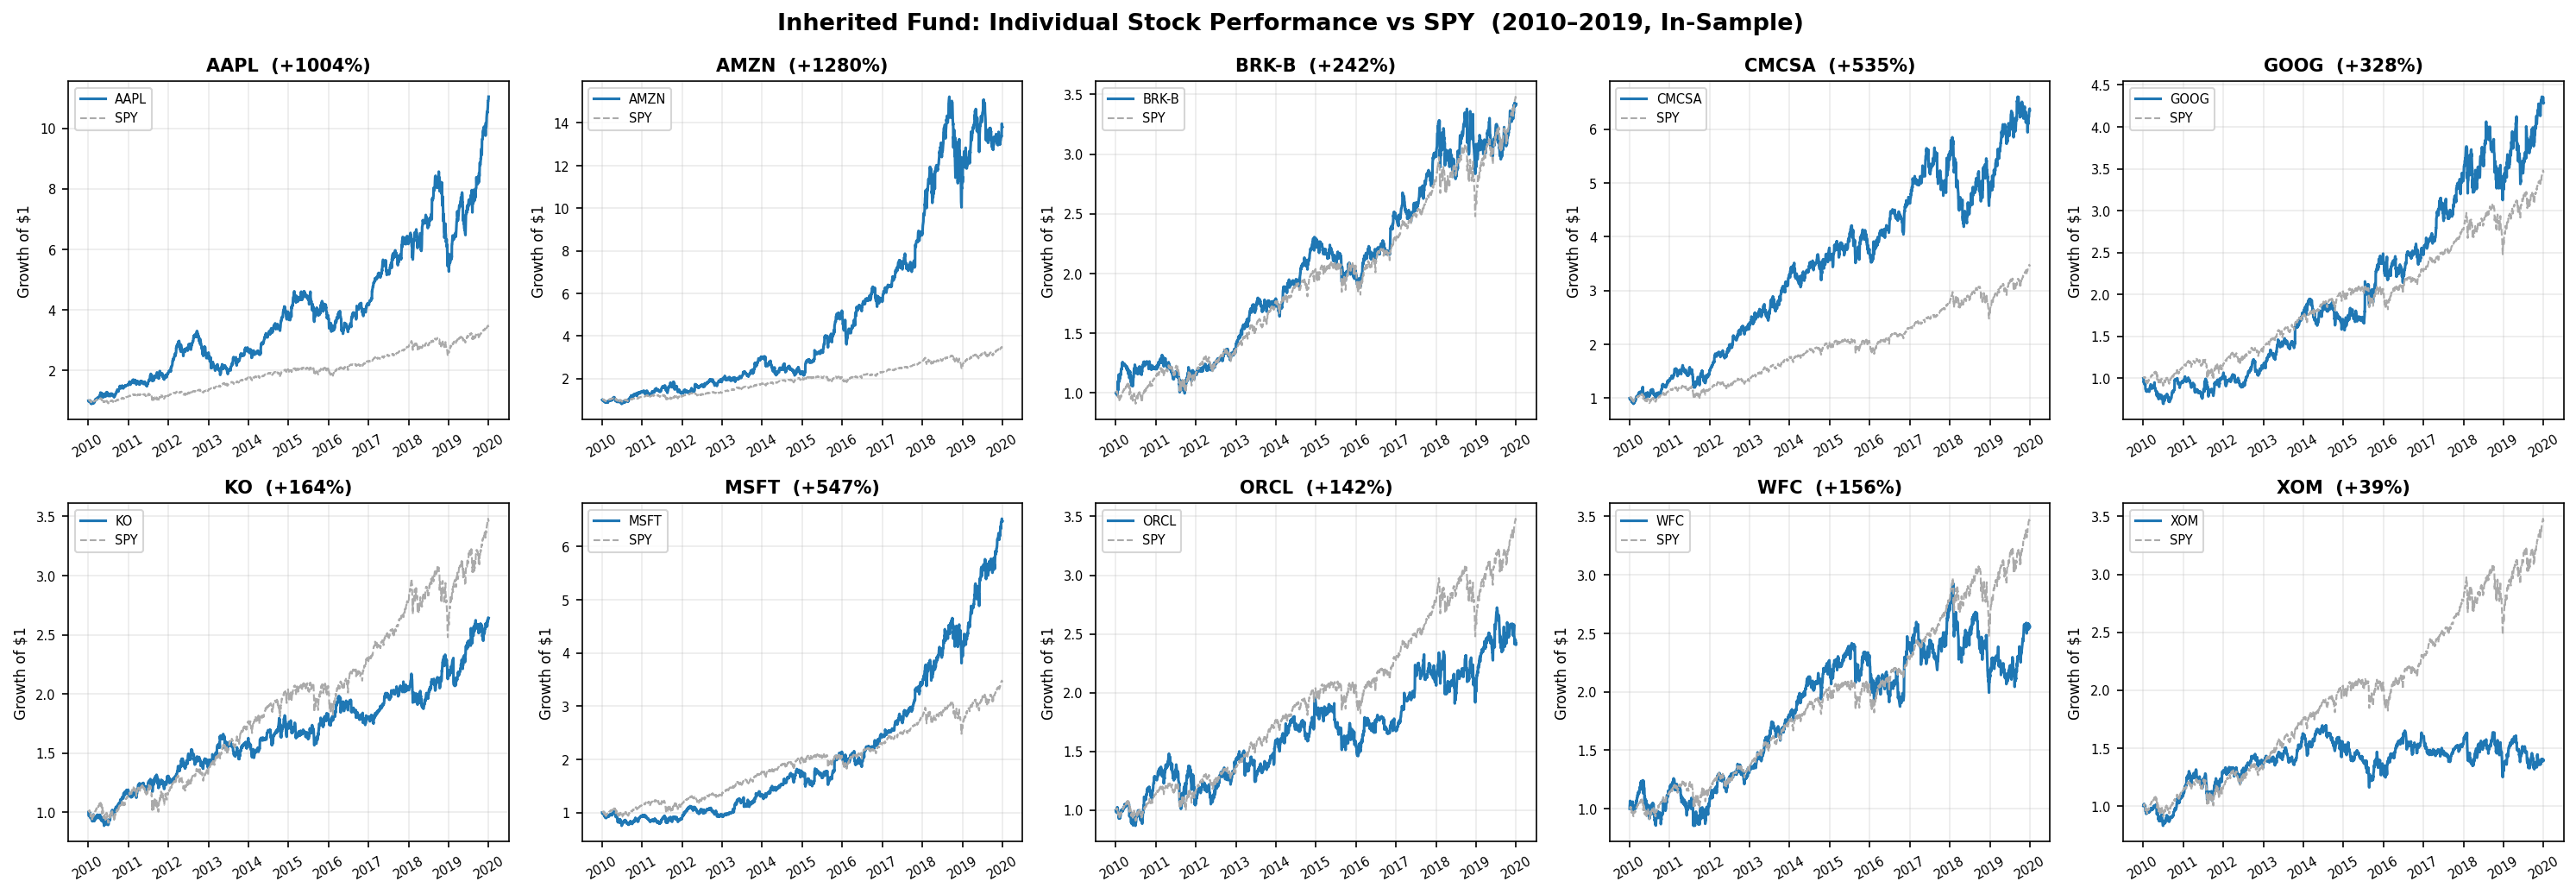

In [7]:
display(Image(str(FIGURES_DIR / "fig_audit_grid_returns.png"), width=1100))

### Risk vs Return (2010–2019)

Each stock plotted by annualized volatility (x) and annualized return (y). SPY is the orange star benchmark reference.

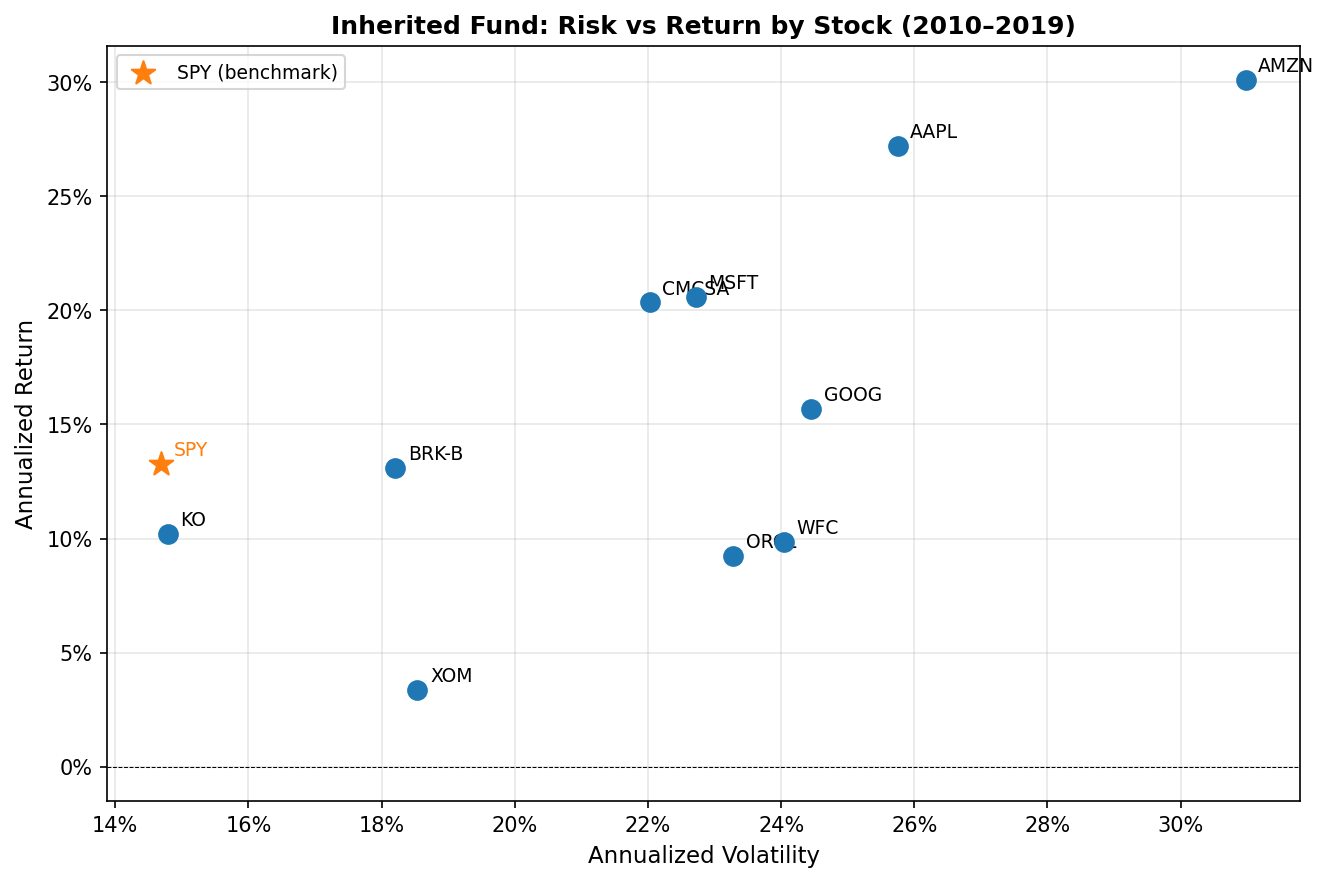

In [8]:
display(Image(str(FIGURES_DIR / "fig_audit_risk_return.png"), width=750))

### Weight Drift — Inception to Decision Date (2019-12-31)

Equal-weight start (10% each) vs how each position drifted by the manager handover date. Stocks that outperformed grew; underperformers shrank.

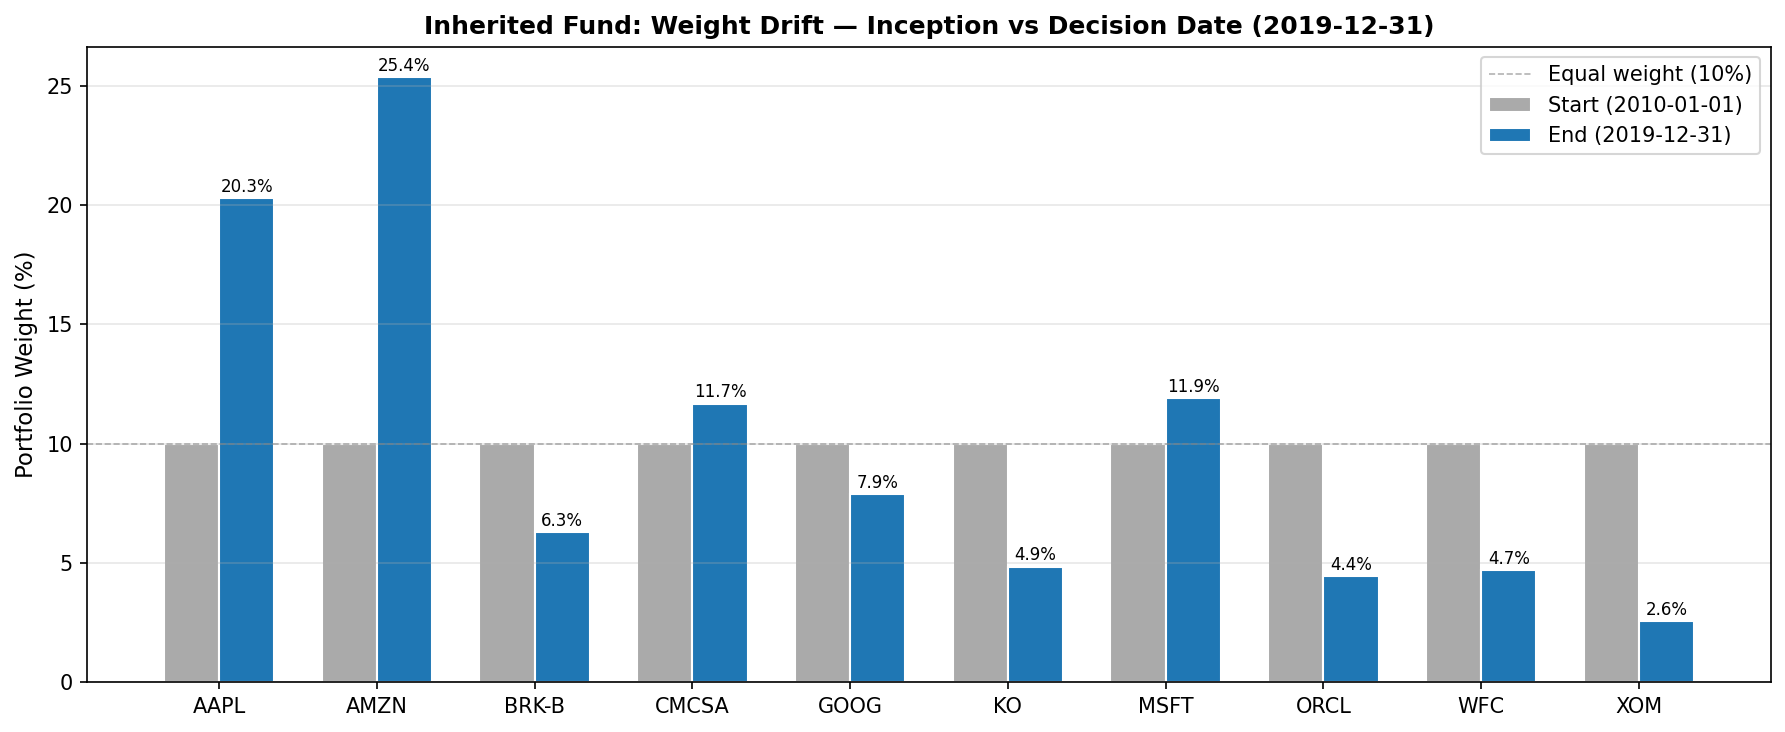

In [9]:
display(Image(str(FIGURES_DIR / "fig_audit_weight_drift.png"), width=900))

### Pairwise Correlation Heatmap (2010–2019)

Red = highly correlated pairs (less diversification benefit). Green = lower correlation (more independent movement).

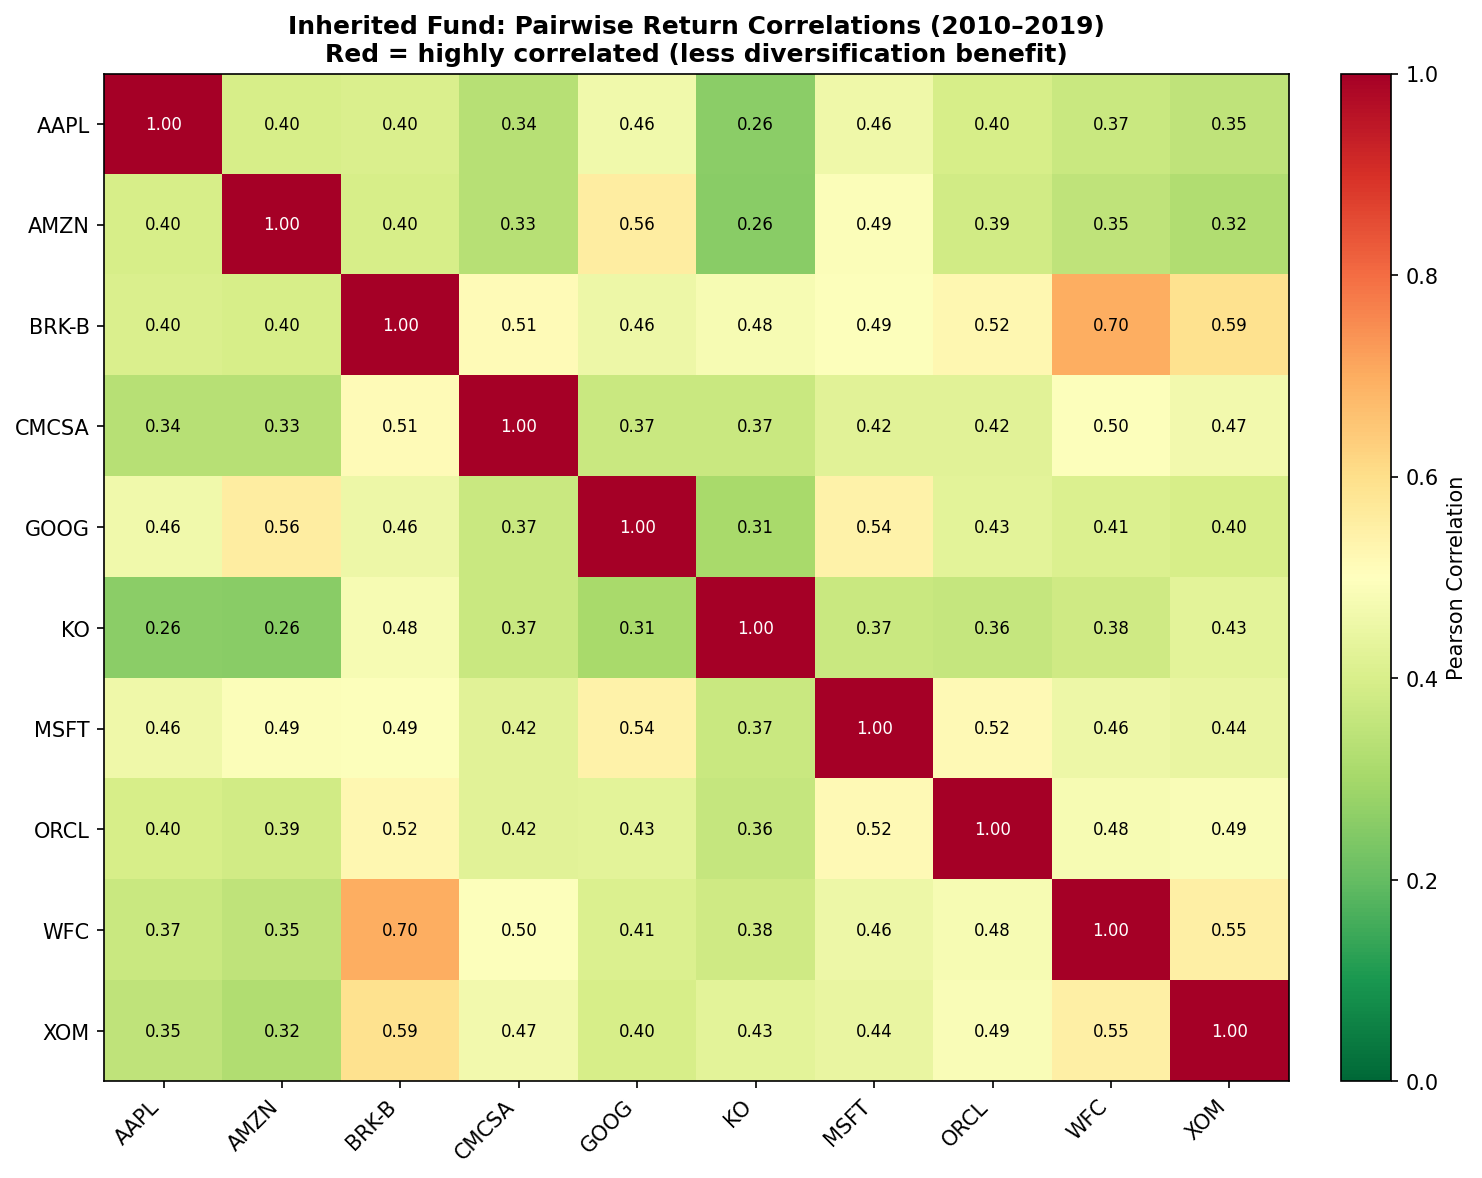

In [10]:
display(Image(str(FIGURES_DIR / "fig_audit_correlation_heatmap.png"), width=750))

### Overall Legacy Fund Performance (Full Period)

In [11]:
tables["performance"]

,portfolio,ending_value,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,turnover
0,Legacy Fund,1.526160e+07,1.757095,0.184686,0.243281,0.759146,1.002198,-0.313778,0.0
1,Revised Static Fund,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Revised Active Fund,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Benchmark,1.267957e+07,1.290636,0.148555,0.207413,0.716228,0.880249,-0.337173,0.0


### Interpretation prompts
- Which inherited names became dominant by January 2020?
- How concentrated did the legacy fund become?
- What are the biggest risks visible in the inherited fund?
- Why might a redesign be justified?


## 3. Candidate Stock Analysis

Required goals:
- research 5–10 candidates
- show screening logic
- justify inclusion or rejection


In [12]:

tables["candidates"]


,candidate_ticker,download_ticker,company_name,sector_theme,thesis_1line,screening_note,add_decision,selected_for_final,target_weight_2020,notes
0,AAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BBB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CCC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DDD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EEE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,FFF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GGG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,HHH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,III,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,KKK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:

tables["candidate_screen"].sort_values(by=[c for c in ["sharpe_pre2020", "ann_return_pre2020"] if c in tables["candidate_screen"].columns], ascending=False).head(10)


,candidate_ticker,download_ticker,company_name,sector_theme,thesis_1line,screening_note,add_decision,selected_for_final,status,first_date,...,sharpe_pre2020,max_drawdown_pre2020,return_1y_pre2020,return_3m_pre2020,vol_63d_pre2020,current_drawdown_pre2020,corr_to_legacy_pre2020,corr_to_benchmark_pre2020,beta_to_benchmark_pre2020,notes


### Interpretation prompts
- What is your candidate universe?
- Why do these names fit your theme or diversification goal?
- Which candidates look strongest by the pre-2020 screen?
- Which names did you reject, and why?


## 4. Revised Fund Design

Required goals:
- explain which original names were kept or dropped
- explain which new names were added
- explain target weights


In [14]:

tables["portfolio"]


,ticker,source,decision,selected_for_final,static_weight,latest_active_weight,notes
0,AAPL,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
1,AMZN,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
2,BRK-B,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
3,CMCSA,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
4,GOOG,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
5,KO,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
6,MSFT,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
7,ORCL,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
8,WFC,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.
9,XOM,Inherited,Legacy hold,Yes,0.1,0.1,Starter default: legacy equal-weight fund.


### Interpretation prompts
- Which inherited holdings did you keep?
- Which inherited holdings did you drop?
- Which new stocks entered the final 10-stock fund?
- Are the weights intuitive, or are they too concentrated?


## 5. Backtest and Performance Evaluation

Required comparison:
- Legacy Fund
- Revised Static Fund
- Revised Active Fund
- benchmark


In [15]:

tables["static_compare"].head()


,status,notes
0,not_started,Revised static backtest is not ready yet.


In [16]:

tables["active_compare"].head()


,status,notes
0,pending,Revised active backtest is not ready yet.


In [17]:

tables["performance"]


,portfolio,ending_value,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,turnover
0,Legacy Fund,1.526160e+07,1.757095,0.184686,0.243281,0.759146,1.002198,-0.313778,0.0
1,Revised Static Fund,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Revised Active Fund,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Benchmark,1.267957e+07,1.290636,0.148555,0.207413,0.716228,0.880249,-0.337173,0.0


### Interpretation prompts
- Did the static redesign improve the inherited fund?
- Did active management improve the static redesign?
- How large are the tradeoffs in return, risk, drawdown, and turnover?
- Are any results too good to trust without caution?


## 6. Factor / Regression Analysis

Required goal:
- explain portfolio behavior with at least one factor/regression-based section


In [18]:

tables["factor_capm"]


,portfolio,n_obs,alpha_daily,alpha_ann,beta,alpha_tstat,alpha_pvalue,beta_tstat,beta_pvalue,r_squared,corr_to_benchmark,market_proxy,risk_free_assumption,notes
0,Legacy Fund,1508,0.000126,0.031635,1.064891,0.755868,0.449846,83.847168,0.0,0.823578,0.907512,benchmark_return,0.0,Starter CAPM uses the benchmark daily return a...


In [19]:

tables["factor_rolling_beta"].head()


,date,portfolio,rolling_beta,window
0,2020-01-02,Legacy Fund,NaN,63
1,2020-01-03,Legacy Fund,NaN,63
2,2020-01-06,Legacy Fund,NaN,63
3,2020-01-07,Legacy Fund,NaN,63
4,2020-01-08,Legacy Fund,NaN,63


### Interpretation prompts
- What do alpha and beta suggest for each portfolio?
- How stable or unstable is beta over time?
- Does the active fund materially change market exposure?


## 7. Scenario / Stress Analysis

Required goal:
- show at least one simulation or stress-testing block


In [20]:

tables["scenario_mc_summary"]


,status,notes
0,pending,Scenario/stress outputs are not ready yet.


In [21]:

tables["scenario_stress"]


,status,notes
0,pending,Scenario/stress outputs are not ready yet.


### Interpretation prompts
- Which portfolio looks most resilient under simulated stress?
- Which scenario hurts the revised fund most?
- Does the redesign improve resilience relative to the legacy fund?


## 8. Final Recommendation

Write your manager recommendation here.

You should answer:
- Should the inherited fund be changed?
- What is your revised recommendation?
- Why is it better?
- What risks remain?
- Under what conditions might it fail?


## 9. Limitations

Be explicit and honest.
- data limitations
- model limitations
- sensitivity to assumptions
- implementation realism
- possible overfitting


## 10. Appendix

Use this section for:
- extra tables
- extra charts
- robustness checks
- parameter sensitivity
- additional notes


In [22]:

tables["manifest"].tail()


,created_at,artifact_type,artifact_name,relative_path,status,notes
36,2026-04-17 09:51:39,figure,fig_scenario_stress_impacts.png,outputs/figures/fig_scenario_stress_impacts.png,created,NaN
37,2026-04-17 09:51:39,table,yf_prices_raw_20260417_095138.csv,data/raw/yf_prices_raw_20260417_095138.csv,created,NaN
38,2026-04-17 09:51:39,table,prices_adjclose_daily.csv,data/clean/prices_adjclose_daily.csv,created,NaN
39,2026-04-17 09:51:39,table,returns_daily.csv,data/clean/returns_daily.csv,created,NaN
40,2026-04-17 09:51:39,table,tbl_project_manifest.csv,outputs/tables/tbl_project_manifest.csv,created,NaN
